In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
true_time=netCDF['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);

#Restricts the timesteps of the data from timesteps0 to 140
data=netCDF.isel(time=np.arange(0,140+1))
parcel=parcel.isel(time=np.arange(0,140+1))

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# parcel=parcel.isel(time=np.arange(0,400+1))

In [2]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [6]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/job_array/'
with h5py.File(dir2+'lagrangian_binary_array.h5', 'r') as f:
    # Load the dataset by its name
    A_g = f['A_g'][:]
    A_c = f['A_c'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

# #Making Time Matrix
# rows, cols = A.shape[0], A.shape[1]
# T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)

In [3]:
#READING BACK IN
mins_thresh=5
# mins_thresh=10
dir3=dir+'Project_Algorithms/Entrainment/processed_binary_arrays_'+str(mins_thresh)+'mins.h5'
with h5py.File(dir3, 'r') as h5file:
    A_g_Processed_e = h5file['A_g_Processed_e'][:]
    A_g_Processed_d = h5file['A_g_Processed_d'][:]
    A_c_Processed_e = h5file['A_c_Processed_e'][:]
    A_c_Processed_d = h5file['A_c_Processed_d'][:]

In [4]:
#constants
Cp=1004 #Jkg-1K-1
Cv=717 #Jkg-1K-1
Rd=Cp-Cv #Jkg-1K-1
eps=0.608

Lx=data['xf'][-1].item()-data['xf'][0].item() #x length (km)
Ly=data['yf'][-1].item()-data['yf'][0].item() #y length (km)
Np=len(parcel['xh']) #number of lagrangian parcles
dt=data['time'][1].item()/1e9 #sec
dx=(data['xf'][1].item()-data['xf'][0].item())*1e3 #meters
dy=(data['yf'][1].item()-data['yf'][0].item())*1e3 #meters
xs=data['xf'].values*1000
ys=data['yf'].values*1000
zs=data['zf'].values*1000

def zf(z):
    k=z #z is the # level of z
    out=data['zf'].values[k]*1000
    return out
# def rho(x,y,z,t):
#     p=data['prs'].isel(xh=x,yh=y,zh=z,time=t).item()
#     p0=101325 #Pa
#     theta=data['th'].isel(xh=x,yh=y,zh=z,time=t).item()
#     T=theta*(p/p0)**(Rd/Cp)
#     qv=data['qv'].isel(xh=x,yh=y,zh=z,time=t).item()
#     # Tv=T*(1+eps*qv)
#     Tv=T*(eps+qv)/(eps*(1+qv))
#     rho = p/(Rd*Tv)
#     out=rho
#     return out
rho_data=data['rho'].data
def rho(x,y,z,t):
    # out=data['rho'].isel(xh=x,yh=y,zh=z,time=t).item()
    out=rho_data[t,z,y,x]
    return out
def m(t):
    m=0
    #triple sum
    for k in range(len('zh')):
        for j in range(len('yh')):
            for i in range(len('xh')):
                rho_out=rho(i,j,k,t)
                m+=rho_out*(zf(k+1)-zf(k))
    #triple sum
    m=m*dx*dy/Np
    out=m
    return out

In [8]:
#TURN PROCESSING ON OR OFF
PROCESSING=False
PROCESSING=True

def M(A,z,t,type):
    #Get Z Locations
    zs=Z[t,:]
    
    #Essential A_t-A_(t-1)
    D=A[t,:]#-A[t-1,:] #(FOR M THERE IS NO t-1 term)
    
    #Essentially the I function
    z_ind=np.where(zs==z)
    A_z=D[z_ind]
    
    #Esentially the H function (FOR M THERE IS NO H FUNCTION)
    # if type=='e':
    #     A_z[A_z<0]=0 #entrainment
    # if type=='d':
    #     A_z[A_z>0]=0 #detrainment

    #Essentially the sumnation
    A_sum=np.sum(A_z)

    if type=='d': 
        A_sum*=-1

    #CONSTANT
    ############
    m_out=m(t)
    dz=zf(z+1)-zf(z)
    constant=(m_out/Lx/Ly/dz)#/dt) #(FOR M THERE IS NO dt IN THE DENOMINATOR) 
    # constant=1
    A_sum*=constant
    return A_sum

#creates 2d storage array
tlen=len(data['time'])
zlen=len(data['zh'])
profile_array_M_g=np.zeros((tlen,zlen))
profile_array_M_c=np.zeros((tlen,zlen))

#Adding to Profile Array
import itertools
ts = range(0, len(data['time']))  # ts from 0 to 140
zs = range(0, len(data['zh']))   # zs from 0 to 34
for count, (t, z) in enumerate(itertools.product(ts, zs)):
    if np.mod(count,10000)==0: print(f'{count*100/len(ts):.2f}%')

    #GENERAL
    if PROCESSING==False:
        A_sum_g=M(A_g, z,t,type='e'); profile_array_M_g[t,z]+=A_sum_g
    elif PROCESSING==True:
        A_sum_g=M(A_g_Processed_e, z,t,type='e'); profile_array_M_g[t,z]+=A_sum_g

    #CLOUDY
    if PROCESSING==False:
        A_sum_c=M(A_c, z,t,type='e'); profile_array_M_c[t,z]+=A_sum_c
    elif PROCESSING==True:
        A_sum_c=M(A_c_Processed_e, z,t,type='e'); profile_array_M_c[t,z]+=A_sum_c

#SAVING
dir3=dir+'Project_Algorithms/Entrainment/2D_VMF_profiles.h5'
with h5py.File(dir3, "w") as h5f:
    h5f.create_dataset("profile_array_M_g", data=profile_array_M_g)
    h5f.create_dataset("profile_array_M_c", data=profile_array_M_c)
print('done')

0.00%
done


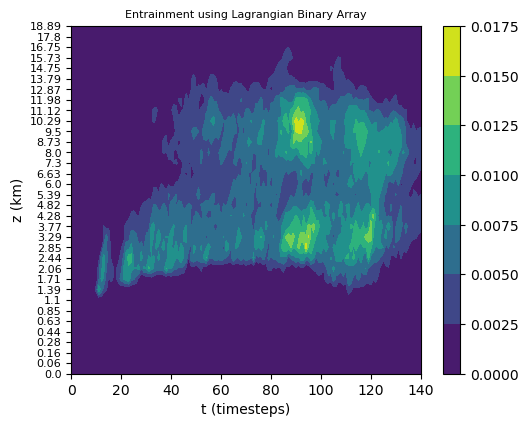

In [14]:
type='general'
type='cloudy'

dir3=dir+'Project_Algorithms/Entrainment/2D_VMF_profiles.h5'
with h5py.File(dir3, "r") as h5f:
    profile_array_M_g = h5f["profile_array_M_g"][:]
    profile_array_M_c = h5f["profile_array_M_c"][:]


if type=='general':
    profile_array=profile_array_M_g
if type=='cloudy':
    profile_array=profile_array_M_c


import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np

fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, figure=fig)

######
cmap1 = plt.cm.viridis
cmap2 = plt.cm.seismic 
n_levels=29
######

# ######
# vmax_shared = np.max([np.max(profile_array_e), np.max(profile_array_d)])
# norm_shared = mcolors.Normalize(vmin=0, vmax=vmax_shared)
# ######

# First subplot: VMF
########################################
ax1 = fig.add_subplot(gs[0, 0])
# contour1 = ax1.contourf(profile_array_e.T, cmap=cmap1)
contour1 = ax1.contourf(profile_array.T, cmap=cmap1)
cbar1=fig.colorbar(contour1, ax=ax1)
Nz = len(data['zh'])
ax1.set_yticks(np.arange(Nz))
new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
ax1.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
ax1.set_ylabel('z (km)');ax1.set_xlabel('t (timesteps)')
ax1.set_title('Entrainment using Lagrangian Binary Array',fontsize=8)

# #FIXING TICKS
# ax3.set_yticks(np.arange(Nz))
# new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
# ax3.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
# ax3.set_ylabel('z (km)');ax3.set_xlabel('t (timesteps)')
# ax3.set_title('Entrainment - Detrainment')

# #FIXING SCIENTIFIC NOTATION
# from matplotlib.ticker import ScalarFormatter
# formatter = ScalarFormatter(useMathText=True)
# formatter.set_powerlimits((-2, 2))  # Adjust the range for scientific notation
# for cbar in (cbar1,cbar2, cbar3):  # These must be Colorbar instances
#     cbar.formatter = formatter
#     cbar.update_ticks()

# Display the plot
plt.tight_layout()

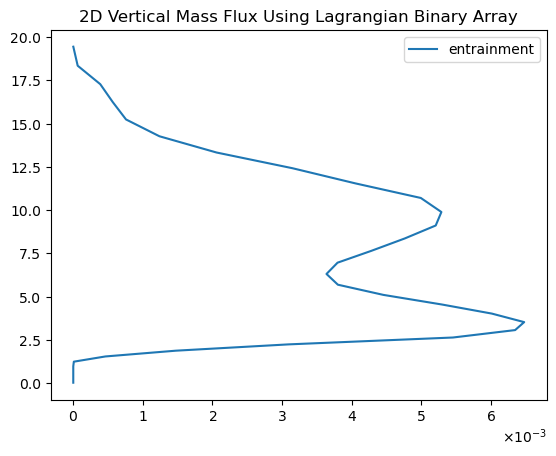

In [15]:
plt.plot(np.mean(profile_array,axis=(0)),data['zh'],label='entrainment')

plt.legend(); plt.title('2D Vertical Mass Flux Using Lagrangian Binary Array')

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))
plt.gca().xaxis.set_major_formatter(formatter)